# 01 — Data Preparation
Load raw parquet files, decode Uniswap v3 events, aggregate to 1-hour feature bars, save `hourly_features.parquet`.

In [4]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
from pathlib import Path
from decode_events import decode_swap_events, decode_mint_events, decode_burn_events

DATA_DIR = Path('../usdc_weth_pool.parquet')
OUT_PATH  = Path('../data/hourly_features.parquet')
OUT_PATH.parent.mkdir(exist_ok=True)

POOL_ADDRESS    = '0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640'  # lower-case for matching
FEE_TIER        = 0.0005   # 0.05 %
TOPIC_MINT  = '0x7a53080ba414158be7ec69b987b5fb7d07dee101fe85488f0853ae16239d0bde'
TOPIC_BURN  = '0x0c396cd989a39f4459b5fa1aed6a9a8dcdbc45908acfd67e028cd568da98982c'
TOPIC_SWAP  = '0xc42079f94a6350d7e6235f29174924f928cc2ac818eb64fed8004e115fbcca67'

# token0 = USDC (6 decimals), token1 = WETH (18 decimals)
USDC_DECIMALS = 6
WETH_DECIMALS = 18

## 1. Load raw parquets

In [5]:
blocks = pd.read_parquet(DATA_DIR / 'blocks.parquet')
logs   = pd.read_parquet(DATA_DIR / 'logs.parquet')

print('blocks:', blocks.shape, list(blocks.columns))
print('logs:  ', logs.shape,   list(logs.columns))
blocks.head(3)

blocks: (6314518, 2) ['number', 'timestamp']
logs:   (10986740, 10) ['log_index', 'transaction_index', 'transaction_hash', 'block_number', 'address', 'data', 'topic0', 'topic1', 'topic2', 'topic3']


,number,timestamp
0,12376729,0x60931133
1,12376891,0x609318e5
2,12376958,0x60931bdd


In [6]:
logs.head(3)

,log_index,transaction_index,transaction_hash,block_number,address,data,topic0,topic1,topic2,topic3
0,106,59,0x125e0b641d4a4b08806bf52c0c6757648c9963bcda86...,12376729,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,0x000000000000000000000000c36442b4a4522e871399...,0x7a53080ba414158be7ec69b987b5fb7d07dee101fe85...,0x000000000000000000000000c36442b4a4522e871399...,0x00000000000000000000000000000000000000000000...,0x00000000000000000000000000000000000000000000...
1,73,72,0x0804ff007263a885191f23c808a9346e62d502a1fc23...,12376891,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,0xffffffffffffffffffffffffffffffffffffffffffff...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x000000000000000000000000e592427a0aece92de3ed...,0x000000000000000000000000e592427a0aece92de3ed...,None
2,122,126,0x7258050fbb90fa41f73505c552a973113ffc87c67ddd...,12376958,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,0x00000000000000000000000000000000000000000000...,0x0c396cd989a39f4459b5fa1aed6a9a8dcdbc45908acf...,0x000000000000000000000000c36442b4a4522e871399...,0x00000000000000000000000000000000000000000000...,0x00000000000000000000000000000000000000000000...


## 2. Filter to pool address & join timestamps

In [8]:
# Normalise address column (HyperSync returns checksummed hex; we lower-case both sides)
logs['address'] = logs['address'].str.lower()
pool_logs = logs[logs['address'] == POOL_ADDRESS].copy()

print(f'Pool log events: {len(pool_logs):,}')

# Join block timestamp
pool_logs = pool_logs.merge(
    blocks[['number', 'timestamp']].rename(columns={'number': 'block_number'}),
    on='block_number', how='left'
)

# Converting timestamps from hex to int, handling nulls
pool_logs["timestamp"] = (
    pool_logs["timestamp"]
    .map(lambda x: int(x, 16) if pd.notna(x) else pd.NA)
    .astype("Int64")
)


# Order pool by block_number, transaction_index, log_index
pool_logs = pool_logs.sort_values(['block_number',
                                    'transaction_index', 
                                    'log_index']).reset_index(drop=True)
print('Null timestamps:', pool_logs['timestamp'].isna().sum())
pool_logs.head(3)

Pool log events: 10,986,740
Null timestamps: 0


,log_index,transaction_index,transaction_hash,block_number,address,data,topic0,topic1,topic2,topic3,timestamp
0,106,59,0x125e0b641d4a4b08806bf52c0c6757648c9963bcda86...,12376729,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,0x000000000000000000000000c36442b4a4522e871399...,0x7a53080ba414158be7ec69b987b5fb7d07dee101fe85...,0x000000000000000000000000c36442b4a4522e871399...,0x00000000000000000000000000000000000000000000...,0x00000000000000000000000000000000000000000000...,1620250931
1,73,72,0x0804ff007263a885191f23c808a9346e62d502a1fc23...,12376891,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,0xffffffffffffffffffffffffffffffffffffffffffff...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x000000000000000000000000e592427a0aece92de3ed...,0x000000000000000000000000e592427a0aece92de3ed...,None,1620252901
2,122,126,0x7258050fbb90fa41f73505c552a973113ffc87c67ddd...,12376958,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,0x00000000000000000000000000000000000000000000...,0x0c396cd989a39f4459b5fa1aed6a9a8dcdbc45908acf...,0x000000000000000000000000c36442b4a4522e871399...,0x00000000000000000000000000000000000000000000...,0x00000000000000000000000000000000000000000000...,1620253661


In [9]:
import importlib
importlib.reload(sys.modules['decode_events'])  # reload to reflect recent edits

swaps = pool_logs[pool_logs['topic0'] == TOPIC_SWAP].copy()
mints = pool_logs[pool_logs['topic0'] == TOPIC_MINT].copy()
burns = pool_logs[pool_logs['topic0'] == TOPIC_BURN].copy()

print(f'Swaps: {len(swaps):,}  Mints: {len(mints):,}  Burns: {len(burns):,}')

swaps = decode_swap_events(swaps)
mints = decode_mint_events(mints)
burns = decode_burn_events(burns)

swaps[['timestamp','amount0','amount1','sqrtPriceX96','tick']].head(3)

Swaps: 10,576,019  Mints: 196,195  Burns: 214,526


,timestamp,amount0,amount1,sqrtPriceX96,tick
1,1620252901,-119744094,35000000000000000,1358206768703179146794161129278934,194996
6,1620257875,499756414,-144241064315415179,1334545912983135722438993170925379,194645
9,1620258696,365000000,-103492428467657963,1334315597745343730478188229716159,194641


In [ ]:
# # Fuck speed if it doesn't work at all
# import pandas as pd
# import dask.dataframe as dd
# importlib.reload(dd)

# # Define your fast partition-level functions
# def to_uint_series(series: pd.Series) -> pd.Series:
#     return pd.Series(
#         [int(x, 16) if isinstance(x, str) and x else 0 for x in series],
#         index=series.index
#     )

# def to_int256_series(series: pd.Series) -> pd.Series:
#     uints = to_uint_series(series)
#     return pd.Series(
#         [x - 2**256 if x >= 2**255 else x for x in uints],
#         index=series.index
#     )

# def decode_mint_events_dask(ddf):
#     # ddf is a Dask DataFrame, not a Pandas DataFrame
#     data_clean = ddf["data"].str[2:]

#     # For string manipulation, Dask mimics Pandas
#     sender = "0x" + data_clean.str.slice(24, 64)
#     owner = "0x" + ddf["topic1"].str[26:]
    
#     # Use map_partitions to apply your Python functions to chunked series in parallel
#     amount = data_clean.str.slice(64, 128).map_partitions(to_uint_series, meta=('amount', 'object'))
#     amount0 = data_clean.str.slice(128, 192).map_partitions(to_uint_series, meta=('amount0', 'object'))
#     amount1 = data_clean.str.slice(192, 256).map_partitions(to_uint_series, meta=('amount1', 'object'))
    
#     tickLower = ddf["topic2"].map_partitions(to_int256_series, meta=('tickLower', 'object'))
#     tickUpper = ddf["topic3"].map_partitions(to_int256_series, meta=('tickUpper', 'object'))

#     # Assign new columns to the Dask DataFrame (lazy assignment)
#     ddf = ddf.assign(
#         sender=sender,
#         owner=owner,
#         amount=amount,
#         amount0=amount0,
#         amount1=amount1,
#         tickLower=tickLower,
#         tickUpper=tickUpper
#     )
#     return ddf


# mint_ddf = dd.from_pandas(pool_logs[pool_logs['topic0'] == TOPIC_MINT], npartitions=4) # Use your number of CPU cores

# # 2. Build the task graph (instant, lazy evaluation)
# mint_ddf = decode_mint_events_dask(mint_ddf)

# # 3. Compute in parallel (this is where the 4.5 minutes gets drastically reduced)
# final_pandas_df = mint_ddf.compute()
# final_pandas_df.head()

,log_index,transaction_index,transaction_hash,block_number,address,data,topic0,topic1,topic2,topic3,timestamp,sender,owner,amount,amount0,amount1,tickLower,tickUpper
0,106,59,0x125e0b641d4a4b08806bf52c0c6757648c9963bcda86...,12376729,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,0x000000000000000000000000c36442b4a4522e871399...,0x7a53080ba414158be7ec69b987b5fb7d07dee101fe85...,0x000000000000000000000000c36442b4a4522e871399...,0x00000000000000000000000000000000000000000000...,0x00000000000000000000000000000000000000000000...,1620250931,0xc36442b4a4522e871399cd717abdd847ab11fe88,0xc36442b4a4522e871399cd717abdd847ab11fe88,345073104699360,2995507735,999999999871526563,191150,198080
4,195,132,0xa564ea4677bda271bbb2eebec9774577b9b101c46eaf...,12377035,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,0x000000000000000000000000c36442b4a4522e871399...,0x7a53080ba414158be7ec69b987b5fb7d07dee101fe85...,0x000000000000000000000000c36442b4a4522e871399...,0x00000000000000000000000000000000000000000000...,0x00000000000000000000000000000000000000000000...,1620254651,0xc36442b4a4522e871399cd717abdd847ab11fe88,0xc36442b4a4522e871399cd717abdd847ab11fe88,25652705721581,1000000,145737680853531,194990,195010
5,286,253,0xef93747acabe06ab11f663321f0de466bf9ae35888ba...,12377266,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,0x000000000000000000000000c36442b4a4522e871399...,0x7a53080ba414158be7ec69b987b5fb7d07dee101fe85...,0x000000000000000000000000c36442b4a4522e871399...,0x00000000000000000000000000000000000000000000...,0x00000000000000000000000000000000000000000000...,1620257679,0xc36442b4a4522e871399cd717abdd847ab11fe88,0xc36442b4a4522e871399cd717abdd847ab11fe88,447994594415865,598469729,2599999995846641821,186730,195460
7,355,145,0x5f066eb8fefba0d1b491ffb924b708dc24158192a77f...,12377308,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,0x000000000000000000000000c36442b4a4522e871399...,0x7a53080ba414158be7ec69b987b5fb7d07dee101fe85...,0x000000000000000000000000c36442b4a4522e871399...,0x00000000000000000000000000000000000000000000...,0x00000000000000000000000000000000000000000000...,1620258289,0xc36442b4a4522e871399cd717abdd847ab11fe88,0xc36442b4a4522e871399cd717abdd847ab11fe88,3508224747038658,3405610348,0,194660,194990
8,105,55,0x5184d8d442ac1696e9f7fb89c31db8c1de8ae9c80f3e...,12377327,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,0x000000000000000000000000c36442b4a4522e871399...,0x7a53080ba414158be7ec69b987b5fb7d07dee101fe85...,0x000000000000000000000000c36442b4a4522e871399...,0x00000000000000000000000000000000000000000000...,0x00000000000000000000000000000000000000000000...,1620258499,0xc36442b4a4522e871399cd717abdd847ab11fe88,0xc36442b4a4522e871399cd717abdd847ab11fe88,35118767990408024,1549658850,151652526935341123,194640,194660


## 4. Compute USDC price from sqrtPriceX96
$$P_{\text{raw}} = \left(\frac{\text{sqrtPriceX96}}{2^{96}}\right)^2$$
Adjusted for decimals (token0=USDC 6dec, token1=WETH 18dec):
$$P_{\text{USDC per WETH}} = P_{\text{raw}} \times 10^{(18 - 6)} = P_{\text{raw}} \times 10^{12}$$

In [ ]:
# Compute WETH price in USDC from tick (and from sqrtPriceX96 with correct inversion), then compare
DECIMAL_ADJ = 10 ** (WETH_DECIMALS - USDC_DECIMALS)  # Adjust for decimals: 6 - 18 = -12
TWO_96 = 2 ** 96

swaps['price_eth_from_tick'] = DECIMAL_ADJ / np.power(1.0001, swaps['tick'])

swaps['price_eth_from_sqrt'] = DECIMAL_ADJ / (
    (swaps['sqrtPriceX96'].astype('float64') / TWO_96) ** 2
)


## 5. Aggregate to 1-hour bars

In [16]:
def assign_time_windows(df):
    df['window'] = (np.floor((df['timestamp'] - min(df['timestamp'])) / 3600)).astype(int)
    return df

swaps = assign_time_windows(swaps)
mints = assign_time_windows(mints)
burns = assign_time_windows(burns)

swaps.tail()

,log_index,transaction_index,transaction_hash,block_number,address,data,topic0,topic1,topic2,topic3,...,sender,recipient,amount0,amount1,sqrtPriceX96,liquidity,tick,price_eth_from_tick,price_eth_from_sqrt,window
10986734,8,2,0x5f58593cf276052d9e511712fd0c7da2e53fc4b53ca2...,24576631,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,0xffffffffffffffffffffffffffffffffffffffffffff...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x000000000000000000000000fbd4cdb413e45a52e2c8...,0x000000000000000000000000fbd4cdb413e45a52e2c8...,None,...,0xfbd4cdb413e45a52e2c8312f670e9ce67e794c37,0xfbd4cdb413e45a52e2c8312f670e9ce67e794c37,-80560440095,41154814033703104063,1790389875989303768267542193176332,14520114637482513658,200522,1.958284e-21,0.0,42301
10986735,12,3,0x66b2201ed6663d01ff8d4884428e534b50283260b390...,24576631,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,0xffffffffffffffffffffffffffffffffffffffffffff...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x000000000000000000000000990636ecb3ff04d33d92...,0x000000000000000000000000990636ecb3ff04d33d92...,None,...,0x990636ecb3ff04d33d92e970d3d588bf5cd8d086,0x990636ecb3ff04d33d92e970d3d588bf5cd8d086,-5167103651,2640000000000000000,1790404273793527949330744218851496,14520114637482513658,200522,1.958284e-21,0.0,42301
10986736,236,44,0x43666d04b21183a07896b3ce71eccbc4e83b4dc5d54f...,24576631,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,0xffffffffffffffffffffffffffffffffffffffffffff...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x00000000000000000000000063242a4ea82847b20e50...,0x00000000000000000000000063242a4ea82847b20e50...,None,...,0x63242a4ea82847b20e506b63b0e2e2eff0cc6cb0,0x63242a4ea82847b20e506b63b0e2e2eff0cc6cb0,-962944967,491996897650080549,1790406957003759491114049354013827,14520114637482513658,200522,1.958284e-21,0.0,42301
10986737,590,144,0x29c8aaa204a19aee33aea7d3fdd75640e3013c53aa85...,24576631,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,0x00000000000000000000000000000000000000000000...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x000000000000000000000000639d19c5c33363e26cde...,0x000000000000000000000000639d19c5c33363e26cde...,None,...,0x639d19c5c33363e26cde548c16cb0562ee0d4115,0x639d19c5c33363e26cde548c16cb0562ee0d4115,4157846,-2122245069547896,1790406945423852481895752815813561,14520114637482513658,200522,1.958284e-21,0.0,42301
10986738,612,144,0x29c8aaa204a19aee33aea7d3fdd75640e3013c53aa85...,24576631,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,0x00000000000000000000000000000000000000000000...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x000000000000000000000000639d19c5c33363e26cde...,0x000000000000000000000000639d19c5c33363e26cde...,None,...,0x639d19c5c33363e26cde548c16cb0562ee0d4115,0x639d19c5c33363e26cde548c16cb0562ee0d4115,4041659,-2062940900899979,1790406934167535225838325595604125,14520114637482513658,200522,1.958284e-21,0.0,42301


In [17]:
# --- Swap aggregations ---
def first_price(s):  return s.iloc[0]
def last_price(s):   return s.iloc[-1]

swap_agg = swaps.groupby('window').agg(
    swap_count=('amount0', 'count'),
    price_first=('price_eth_from_tick', first_price),
    price_last=('price_eth_from_tick', last_price),
    tick_std=('tick', 'std'),            # proxy for realised volatility
    abs_amount0_sum=('amount0', lambda x: x.abs().sum()),  # raw USDC units (6-dec)
).reset_index()

# log-return
swap_agg['log_return'] = np.log(swap_agg['price_last'] / swap_agg['price_first'])

# realised volatility = std of per-swap tick changes; 0 if only 1 swap in window
swap_agg['realised_vol'] = swap_agg['tick_std'].fillna(0.0)

# fees in USDC: fee = |amount0_i| * fee_tier, amount0 in raw units / 1e6 = USDC
swap_agg['total_fees_usd'] = (swap_agg['abs_amount0_sum'] / 10**USDC_DECIMALS) * FEE_TIER

swap_agg.tail()

,window,swap_count,price_first,price_last,tick_std,abs_amount0_sum,log_return,realised_vol,total_fees_usd
42296,42297,203,2.000640e-21,1.986487e-21,12.795940,8230611988652,-0.007100,12.795940,4115.305994
42297,42298,502,1.986685e-21,1.965739e-21,63.595411,19438665481277,-0.010599,63.595411,9719.332741
42298,42299,325,1.965739e-21,1.947154e-21,28.251986,12672863304109,-0.009500,28.251986,6336.431652
42299,42300,287,1.947154e-21,1.959655e-21,21.669339,10915949898299,0.006400,21.669339,5457.974949
42300,42301,58,1.959655e-21,1.958284e-21,12.684930,2417109915007,-0.000700,12.684930,1208.554958


## 6. Sanity checks

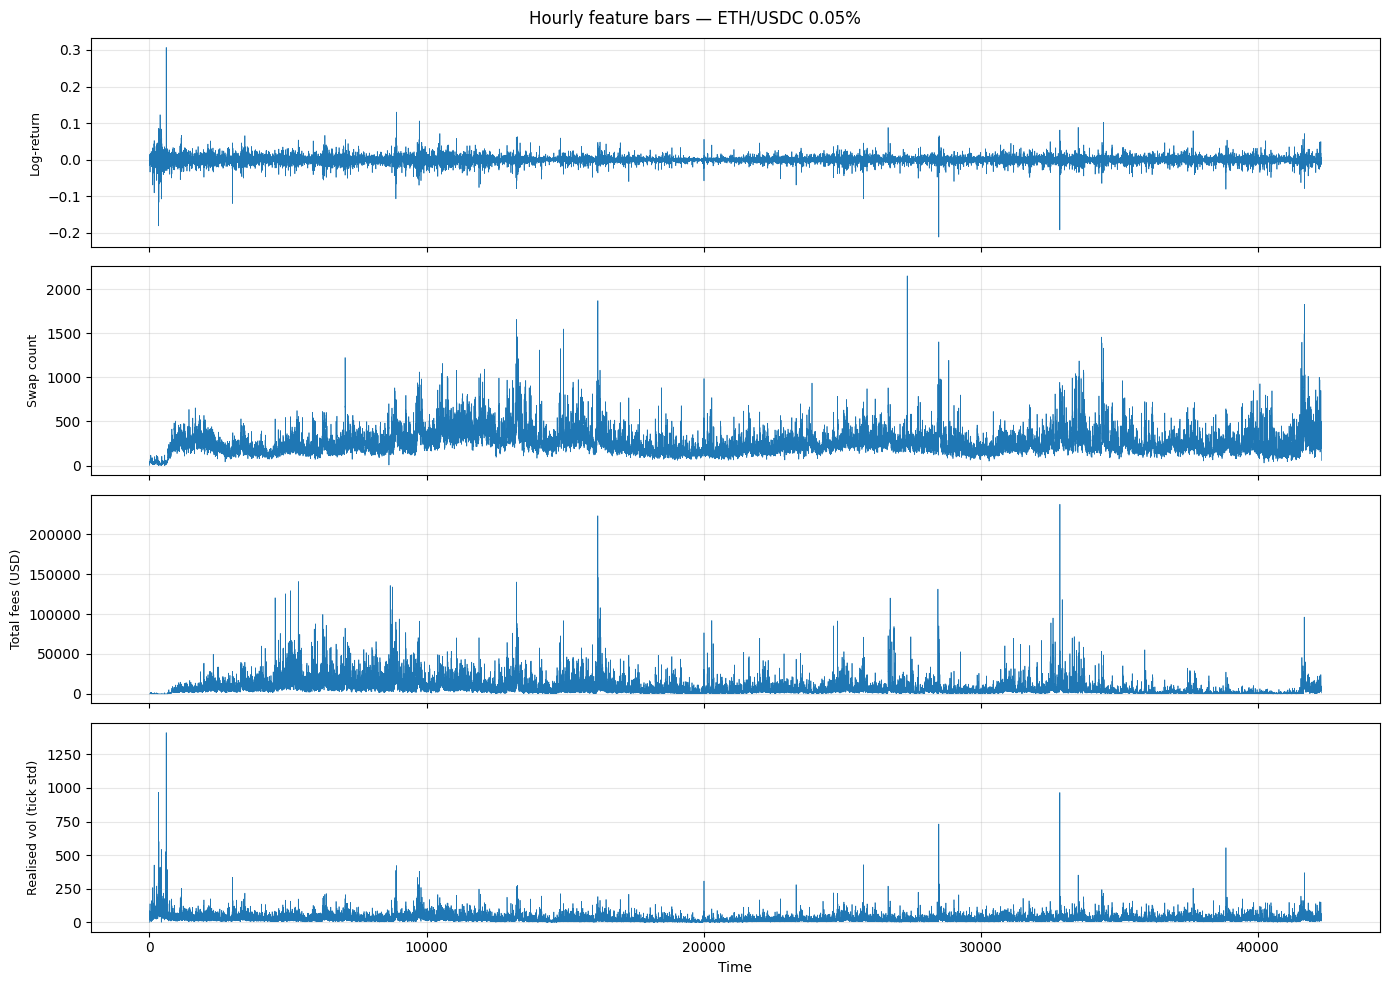

,window,swap_count,price_first,price_last,tick_std,abs_amount0_sum,log_return,realised_vol,total_fees_usd
count,42301.000000,42301.000000,4.230100e+04,4.230100e+04,42299.000000,4.230100e+04,42301.000000,42301.000000,42301.000000
mean,21150.992270,250.018179,2.588322e-21,2.588297e-21,24.396204,1.385029e+13,-0.000006,24.395050,6925.144872
std,12211.404491,127.786303,9.007926e-22,9.007613e-22,27.059388,1.796699e+13,0.008404,27.059268,8983.495511
min,0.000000,1.000000,9.081069e-22,9.055679e-22,0.000000,1.197441e+08,-0.211389,0.000000,0.059872
25%,10576.000000,169.000000,1.825898e-21,1.825898e-21,10.428329,3.593432e+12,-0.003000,10.427189,1796.716038
50%,21151.000000,223.000000,2.521000e-21,2.521000e-21,17.433295,8.266309e+12,0.000100,17.431039,4133.154485
75%,31726.000000,298.000000,3.263965e-21,3.263965e-21,29.371504,1.737472e+13,0.003100,29.370903,8687.361165
max,42301.000000,2149.000000,4.934849e-21,4.937317e-21,1411.959331,4.748882e+14,0.306885,1411.959331,237444.081218


In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
cols  = ['log_return', 'swap_count', 'total_fees_usd', 'realised_vol']
titles = ['Log-return', 'Swap count', 'Total fees (USD)', 'Realised vol (tick std)']

for ax, col, title in zip(axes, cols, titles):
    ax.plot(swap_agg['window'], swap_agg[col], lw=0.5)
    ax.set_ylabel(title, fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time')
fig.suptitle('Hourly feature bars — ETH/USDC 0.05%', fontsize=12)
plt.tight_layout()
plt.show()

swap_agg.describe()

## 7. Save

In [19]:
swap_agg.to_parquet(OUT_PATH, index=False)
print(f'Saved → {OUT_PATH}  ({len(swap_agg):,} rows)')

Saved → ..\data\hourly_features.parquet  (42,301 rows)
